Clustering

Import Libraries

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler


Load Dataset

In [10]:
dt = pd.read_csv('global_fuel_prices_2020_2026.csv')
dt.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


Select Numeric Columns

In [11]:
numeric_dt = dt.select_dtypes(include=['int64', 'float64'])
numeric_dt = numeric_dt.dropna()
numeric_dt.head()

,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,1.465,1.289,1.093,65.75,59.6
1,1.435,1.319,1.077,65.54,27.6
2,1.446,1.329,1.080,66.51,62.3
3,1.488,1.359,1.125,68.79,44.8
4,1.457,1.341,1.111,68.44,51.4


Scaling

In [12]:
scaled_num = StandardScaler().fit_transform(numeric_dt)
scaled_num

array([[-0.5302633 , -0.57661598, -0.53523206, -2.15772481,  1.90812432],
       [-0.54973643, -0.5561386 , -0.54907861, -2.16879373,  0.04798755],
       [-0.54259628, -0.5493128 , -0.54648239, -2.11766587,  2.06507336],
       ...,
       [ 0.51284751,  0.47182611,  0.53874109,  1.22883681,  2.16970605],
       [ 0.49532169,  0.4656829 ,  0.49373979,  1.22883681,  0.98386886],
       [ 0.50765467,  0.48616028,  0.50585553,  1.22883681,  2.14645434]],
      shape=(27468, 5))

Find Best K

In [13]:
best_k = 0
best_score = -1

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=10)
    labels = model.fit_predict(scaled_num)

    score = silhouette_score(scaled_num, labels)

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)
print("Best Score:", best_score)

Best K: 2
Best Score: 0.4354077623547347


Final Clustering

In [14]:
final_model = KMeans(n_clusters=best_k, random_state=10)
final_labels = final_model.fit_predict(scaled_num)

numeric_dt['cluster'] = final_labels

print(numeric_dt.head())
print(numeric_dt['cluster'].value_counts())

   petrol_usd_liter  diesel_usd_liter  lpg_usd_liter  brent_crude_usd  \
0             1.465             1.289          1.093            65.75   
1             1.435             1.319          1.077            65.54   
2             1.446             1.329          1.080            66.51   
3             1.488             1.359          1.125            68.79   
4             1.457             1.341          1.111            68.44   

   tax_percentage  cluster  
0            59.6        1  
1            27.6        1  
2            62.3        1  
3            44.8        1  
4            51.4        1  
cluster
1    15540
0    11928
Name: count, dtype: int64


KMEANS (NUMERIC) FULL VISUAL

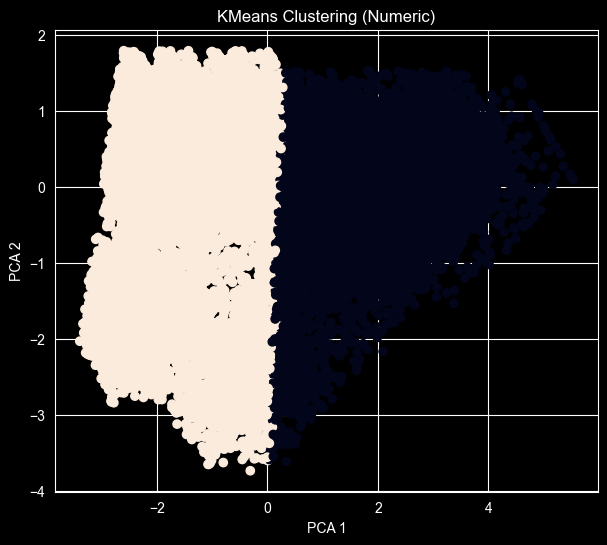

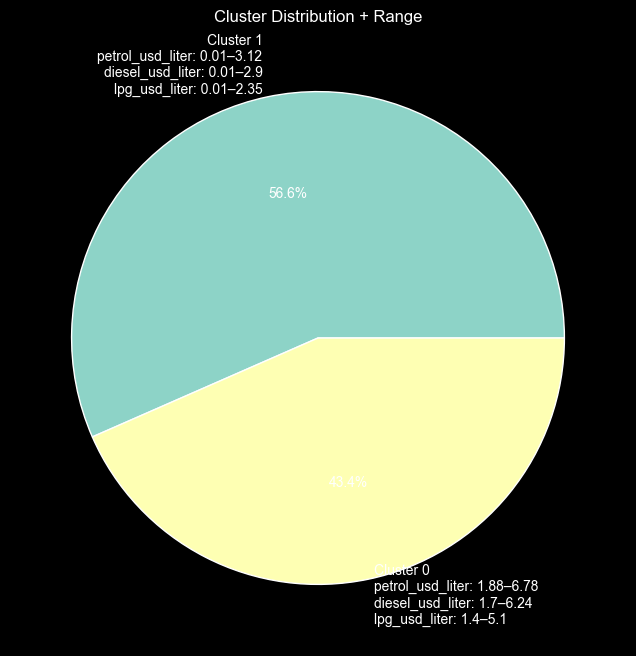

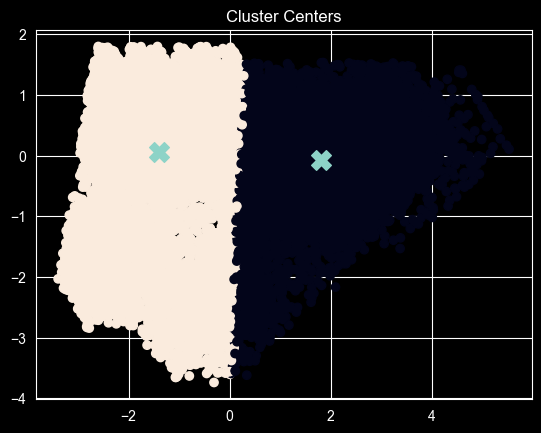

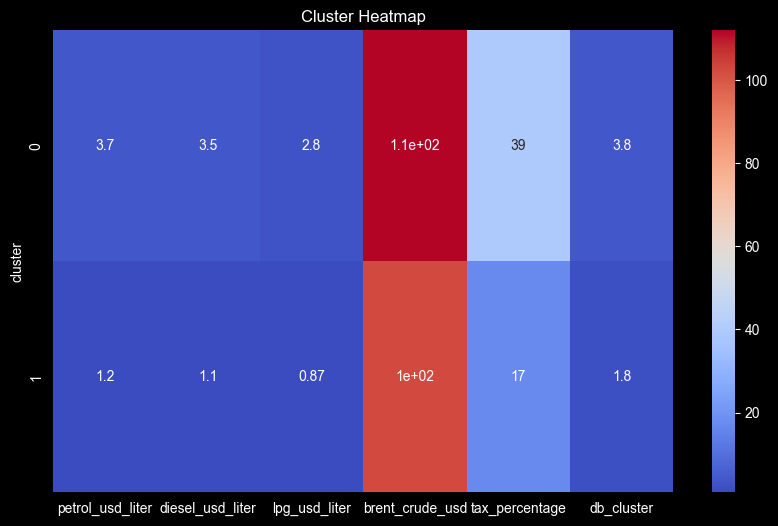

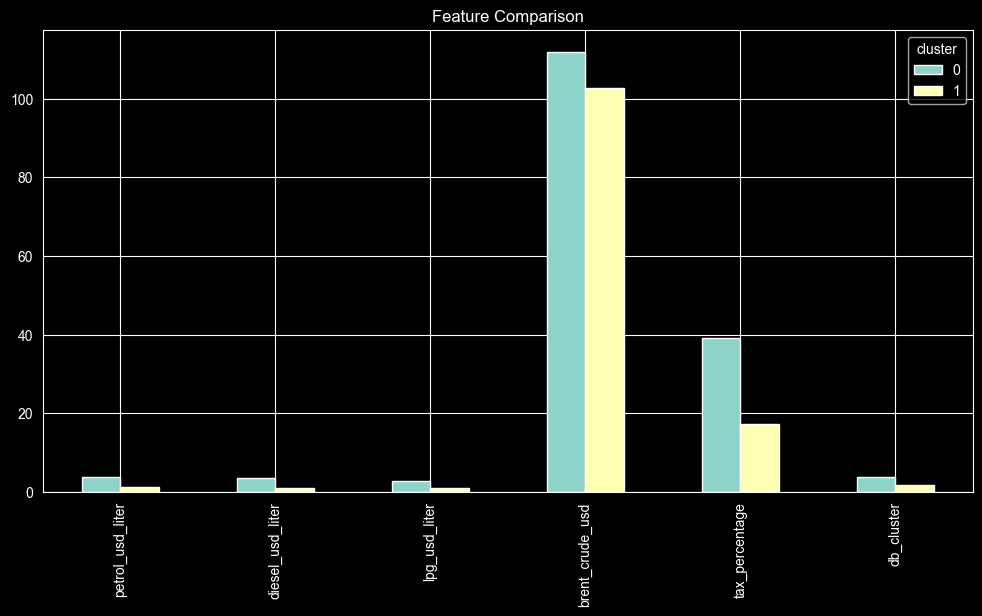


Cluster Range:
         petrol_usd_liter        diesel_usd_liter        lpg_usd_liter         \
                     min    max              min    max           min    max   
cluster                                                                        
0                  1.878  6.779            1.698  6.240         1.396  5.100   
1                  0.010  3.122            0.010  2.904         0.010  2.353   

        brent_crude_usd        tax_percentage       db_cluster      
                    min    max            min   max        min max  
cluster                                                             
0                 47.97  130.0           10.0  65.0         -1  79  
1                 47.97  130.0            0.0  65.0         -1  86  


In [30]:
pca = PCA(n_components=2)
num_pca = pca.fit_transform(scaled_num)

# 1. Scatter
plt.figure(figsize=(7,6))
plt.scatter(num_pca[:,0], num_pca[:,1], c=final_labels)
plt.title("KMeans Clustering (Numeric)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 2. Pie + Range
cluster_counts = numeric_dt['cluster'].value_counts()
cluster_range = numeric_dt.groupby('cluster').agg(['min','max'])

labels = []
for i in cluster_counts.index:
    cols = numeric_dt.columns[:-1][:3]
    text = f"Cluster {i}\n"
    for col in cols:
        mn = cluster_range.loc[i, (col,'min')]
        mx = cluster_range.loc[i, (col,'max')]
        text += f"{col}: {round(mn,2)}–{round(mx,2)}\n"
    labels.append(text)

plt.figure(figsize=(8,8))
plt.pie(cluster_counts, labels=labels, autopct='%1.1f%%')
plt.title("Cluster Distribution + Range")
plt.show()

# 3. Centers
centers = final_model.cluster_centers_
centers_pca = pca.transform(centers)

plt.figure()
plt.scatter(num_pca[:,0], num_pca[:,1], c=final_labels)
plt.scatter(centers_pca[:,0], centers_pca[:,1], marker='X', s=200)
plt.title("Cluster Centers")
plt.show()

# 4. Heatmap
cluster_mean = numeric_dt.groupby('cluster').mean()

plt.figure(figsize=(10,6))
sns.heatmap(cluster_mean, annot=True, cmap='coolwarm')
plt.title("Cluster Heatmap")
plt.show()

# 5. Feature Comparison
cluster_mean.T.plot(kind='bar', figsize=(12,6))
plt.title("Feature Comparison")
plt.show()

# 6. Print Range
print("\nCluster Range:\n", cluster_range)

Drop Date

In [16]:
dt2 = dt.drop('date', axis=1)
dt2

,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4
...,...,...,...,...,...,...,...,...,...
27463,Rwanda,Africa,Low,Low,3.036,2.849,2.294,130.00,62.3
27464,Rwanda,Africa,Low,Low,3.020,2.861,2.248,130.00,43.3
27465,Rwanda,Africa,Low,Low,3.072,2.825,2.334,130.00,64.1
27466,Rwanda,Africa,Low,Low,3.045,2.816,2.282,130.00,43.7


One-Hot Encoding

In [17]:
dt2 = pd.get_dummies(dt2)
dt2 = dt2.dropna()

dt2.head()

,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,country_Algeria,country_Angola,country_Argentina,country_Australia,country_Austria,...,region_North America,region_Oceania,region_South America,income_level_High,income_level_Low,income_level_Middle,subsidy_level_High,subsidy_level_Low,subsidy_level_Medium,subsidy_level_Very High
0,1.465,1.289,1.093,65.75,59.6,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
1,1.435,1.319,1.077,65.54,27.6,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
2,1.446,1.329,1.080,66.51,62.3,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
3,1.488,1.359,1.125,68.79,44.8,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
4,1.457,1.341,1.111,68.44,51.4,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False


Scaling

In [18]:
scaled_all = StandardScaler().fit_transform(dt2)
scaled_all

array([[-0.5302633 , -0.57661598, -0.53523206, ...,  0.95346259,
        -0.52223297, -0.36760731],
       [-0.54973643, -0.5561386 , -0.54907861, ...,  0.95346259,
        -0.52223297, -0.36760731],
       [-0.54259628, -0.5493128 , -0.54648239, ...,  0.95346259,
        -0.52223297, -0.36760731],
       ...,
       [ 0.51284751,  0.47182611,  0.53874109, ...,  0.95346259,
        -0.52223297, -0.36760731],
       [ 0.49532169,  0.4656829 ,  0.49373979, ...,  0.95346259,
        -0.52223297, -0.36760731],
       [ 0.50765467,  0.48616028,  0.50585553, ...,  0.95346259,
        -0.52223297, -0.36760731]], shape=(27468, 103))

Find Best K

In [19]:
best_k2 = 0
best_score2 = -1

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=10)
    labels = model.fit_predict(scaled_all)

    score = silhouette_score(scaled_all, labels)

    if score > best_score2:
        best_score2 = score
        best_k2 = k

print("Best K:", best_k2)
print("Best Score:", best_score2)

Best K: 9
Best Score: 0.11256908592955879


Final Clustering

In [20]:
final_model2 = KMeans(n_clusters=best_k2, random_state=10)
final_labels2 = final_model2.fit_predict(scaled_all)

dt2['cluster'] = final_labels2

print(dt2.head())
print(dt2['cluster'].value_counts())

   petrol_usd_liter  diesel_usd_liter  lpg_usd_liter  brent_crude_usd  \
0             1.465             1.289          1.093            65.75   
1             1.435             1.319          1.077            65.54   
2             1.446             1.329          1.080            66.51   
3             1.488             1.359          1.125            68.79   
4             1.457             1.341          1.111            68.44   

   tax_percentage  country_Algeria  country_Angola  country_Argentina  \
0            59.6            False           False              False   
1            27.6            False           False              False   
2            62.3            False           False              False   
3            44.8            False           False              False   
4            51.4            False           False              False   

   country_Australia  country_Austria  ...  region_Oceania  \
0              False            False  ...           False  

KMEANS (FULL DATA) VISUAL

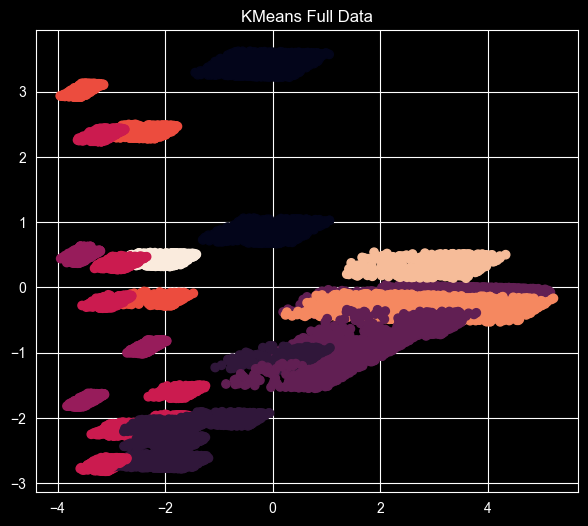

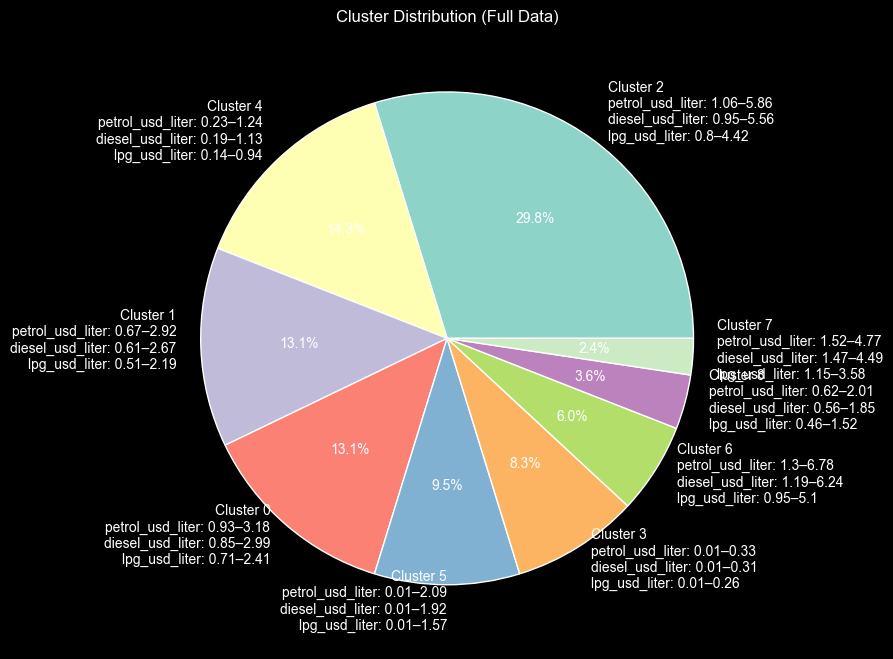

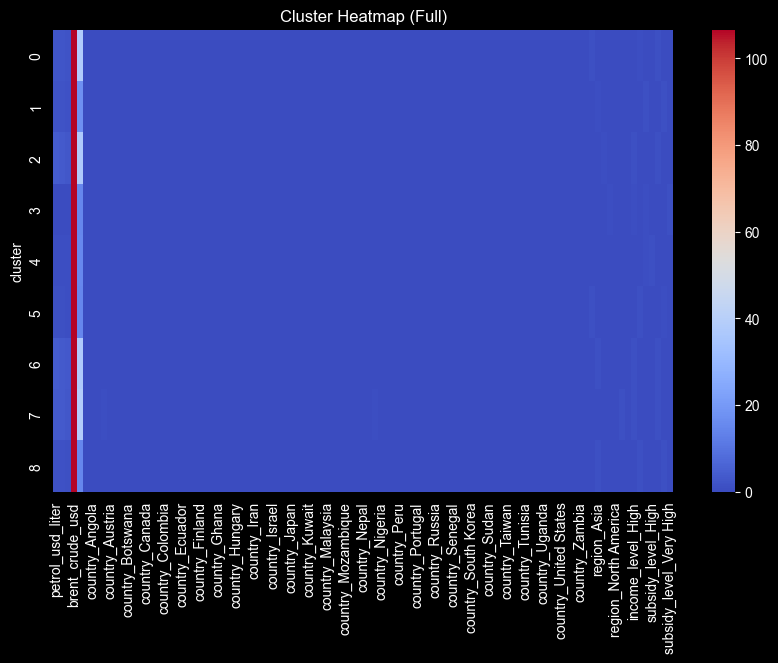

In [31]:
pca2 = PCA(n_components=2)
all_pca = pca2.fit_transform(scaled_all)

# Scatter
plt.figure(figsize=(7,6))
plt.scatter(all_pca[:,0], all_pca[:,1], c=final_labels2)
plt.title("KMeans Full Data")
plt.show()

# Pie + Range
counts2 = dt2['cluster'].value_counts()
range2 = dt2.groupby('cluster').agg(['min','max'])

labels2 = []
for i in counts2.index:
    cols = dt2.columns[:-1][:3]
    text = f"Cluster {i}\n"
    for col in cols:
        mn = range2.loc[i, (col,'min')]
        mx = range2.loc[i, (col,'max')]
        text += f"{col}: {round(mn,2)}–{round(mx,2)}\n"
    labels2.append(text)

plt.figure(figsize=(8,8))
plt.pie(counts2, labels=labels2, autopct='%1.1f%%')
plt.title("Cluster Distribution (Full Data)")
plt.show()

# Heatmap
mean2 = dt2.groupby('cluster').mean()

plt.figure(figsize=(10,6))
sns.heatmap(mean2, cmap='coolwarm')
plt.title("Cluster Heatmap (Full)")
plt.show()

DBSCAN

Import

In [22]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

Find Auto eps

In [23]:
# find nearest neighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaled_num)

distances, indices = neighbors_fit.kneighbors(scaled_num)

# sort distances
distances = np.sort(distances[:, 4])

# auto eps (using percentile)
eps = np.percentile(distances, 90)

print("Auto eps:", eps)

Auto eps: 0.17023439185005262


Apply DBSCAN

In [24]:
dbscan = DBSCAN(eps=eps, min_samples=5)

db_labels = dbscan.fit_predict(scaled_num)

Add Result

In [25]:
numeric_dt['db_cluster'] = db_labels

print(numeric_dt.head())
print(numeric_dt['db_cluster'].value_counts())

   petrol_usd_liter  diesel_usd_liter  lpg_usd_liter  brent_crude_usd  \
0             1.465             1.289          1.093            65.75   
1             1.435             1.319          1.077            65.54   
2             1.446             1.329          1.080            66.51   
3             1.488             1.359          1.125            68.79   
4             1.457             1.341          1.111            68.44   

   tax_percentage  cluster  db_cluster  
0            59.6        1           0  
1            27.6        1           0  
2            62.3        1           0  
3            44.8        1           0  
4            51.4        1           0  
db_cluster
 2     16509
 0      8419
-1      1337
 20      219
 19      134
       ...  
 42        4
 46        4
 82        4
 45        3
 65        2
Name: count, Length: 88, dtype: int64


DBSCAN VISUALIZATION

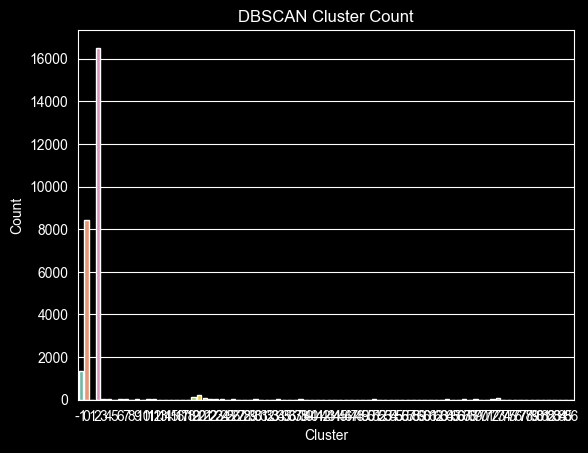

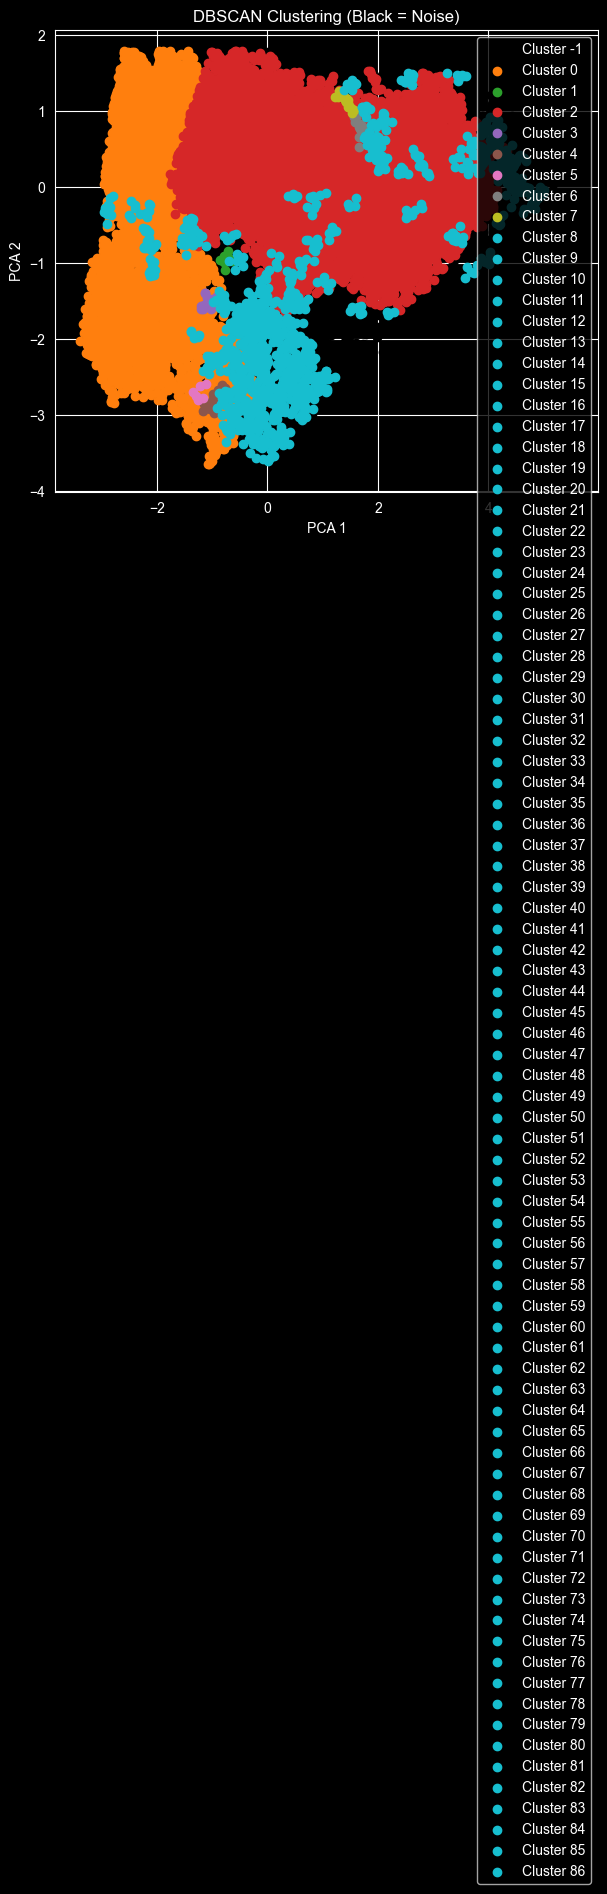

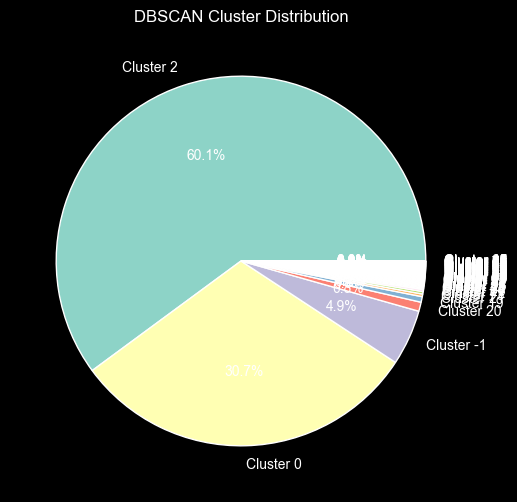

C:\Users\naimul.islam\AppData\Local\Temp\ipykernel_5712\2580014190.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


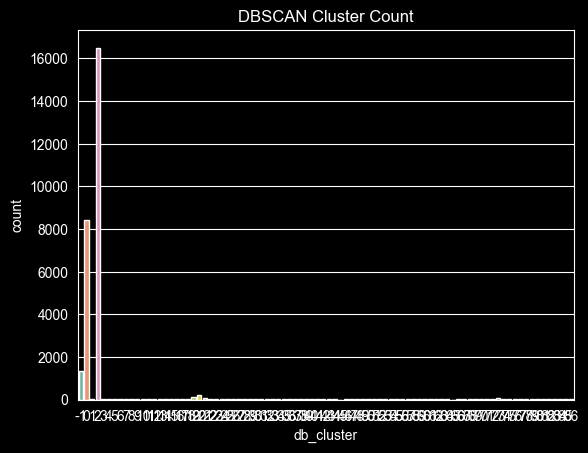

Noise points: 1337


In [34]:
unique_labels = np.unique(db_labels)


plt.figure()

sns.countplot(
    x=numeric_dt['db_cluster'],
    hue=numeric_dt['db_cluster'],
    palette='Set2',
    legend=False
)

plt.title("DBSCAN Cluster Count")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

# assign colors manually
colors = plt.cm.tab10(range(len(unique_labels)))

plt.figure(figsize=(7,6))

for label, color in zip(unique_labels, colors):

    if label == -1:
        color = 'black'   # noise = black

    mask = db_labels == label

    plt.scatter(
        num_pca[mask, 0],
        num_pca[mask, 1],
        label=f"Cluster {label}",
        color=color
    )

plt.legend()
plt.title("DBSCAN Clustering (Black = Noise)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


# ================= PIE (COLOR FIXED) =================

counts_db = numeric_dt['db_cluster'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts_db,
    labels=[f"Cluster {i}" for i in counts_db.index],
    autopct='%1.1f%%',
    colors=plt.cm.Set3(range(len(counts_db)))
)
plt.title("DBSCAN Cluster Distribution")
plt.show()


# ================= BAR (COLOR FIXED) =================

plt.figure()
sns.countplot(
    x=numeric_dt['db_cluster'],
    palette='Set2'
)
plt.title("DBSCAN Cluster Count")
plt.show()


# ================= NOISE INFO =================

noise = (db_labels == -1).sum()
print("Noise points:", noise)